**Goal:** build the three recommenders that need no rating history -- **content-based**
(genre features), **demographic** (cohorts), and **knowledge-based** (rules) -- then
answer L22's open question by **evaluating** the methods you already built: a
train/test split and an RMSE/MAE **accuracy ladder**. Pairs with the concept note
[Content-, Knowledge- & Demographic-Based Recommenders](l23_concept_content_based_recommenders.qmd).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devomh/cdat4001-2026/blob/main/u06_recommender_systems/l23_lab_content_based_recommenders.ipynb)

> This page is the read-only view. To run the lab, open the notebook
> (`l23_lab_content_based_recommenders.ipynb`) -- in Colab via the badge above, or
> locally. Needs network access the first time (it downloads MovieLens 100k).
> Every text output below comes from actually running the cells.

## Prerequisites & Setup

The same **MovieLens 100k** as L22 (GroupLens, U. Minnesota). Its license forbids
redistribution, so the notebook downloads it at run time and checks its md5 -- we do
not bundle it. This lesson uses the columns L22 ignored: the 19 **genre flags** in
`u.item` (content-based) and the **age/gender** in `u.user` (demographic).

In [1]:
# Setup cell 1 of 2: install only (Colab resets on open; run this first)
%pip install -q pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup cell 2 of 2: imports + download + load. Safe to re-run (skips the download once present).
import os, hashlib, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
MD5 = "0e33842e24a9c977be4e0107933c0723"
os.makedirs("data", exist_ok=True)
if not os.path.exists("data/ml-100k/u.data"):
    urllib.request.urlretrieve(URL, "data/ml-100k.zip")
    assert hashlib.md5(open("data/ml-100k.zip", "rb").read()).hexdigest() == MD5, "checksum mismatch"
    with zipfile.ZipFile("data/ml-100k.zip") as z:
        z.extractall("data")

ratings = pd.read_csv("data/ml-100k/u.data", sep="\t", names=["user", "item", "rating", "ts"])
users = pd.read_csv("data/ml-100k/u.user", sep="|", names=["user", "age", "gender", "occupation", "zip"])
GENRES = ["unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
          "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
          "Romance", "Sci-Fi", "Thriller", "War", "Western"]
items = pd.read_csv("data/ml-100k/u.item", sep="|", encoding="latin-1",
                    names=["item", "title", "release", "video", "imdb"] + GENRES)
title = items.set_index("item")["title"]
counts = ratings.groupby("item").rating.count()
print("MovieLens 100k -- GroupLens / U. Minnesota (Harper & Konstan 2015); runtime download, not redistributed.")
print("ratings:", ratings.shape, "| users:", users.shape, "| items:", items.shape)

MovieLens 100k -- GroupLens / U. Minnesota (Harper & Konstan 2015); runtime download, not redistributed.
ratings: (100000, 4) | users: (943, 5) | items: (1682, 24)


<details><summary>Expected Output</summary>

~~~text
MovieLens 100k -- GroupLens / U. Minnesota (Harper & Konstan 2015); runtime download, not redistributed.
ratings: (100000, 4) | users: (943, 5) | items: (1682, 24)
~~~
</details>

## Step 1: Content-Based Filtering (Worked)

Content-based filtering recommends by **item features**. Each movie is a 0/1 vector
over the 19 genres; a user's **content profile** is the sum of the genre vectors of
the movies they rated, weighted by how far each rating sat above their own average
(genres they like come out positive, genres they dislike negative). Then score every
unseen movie by the **cosine** (L18) between its genres and that profile.

In [3]:
G = items.set_index("item").reindex(range(1, 1683))[GENRES].values.astype(float)   # 1682 x 19 genre matrix
gnorm = np.sqrt((G**2).sum(axis=1)); gnorm[gnorm == 0] = 1e-9

def content_recommend(uid, n=5, min_count=50):
    seen = ratings[ratings.user == uid]
    profile = (seen.rating - seen.rating.mean()).values @ G[seen.item.values - 1]   # 19-dim taste profile
    pnorm = np.sqrt((profile**2).sum()) or 1e-9
    sims = (G @ profile) / (gnorm * pnorm)
    sims[seen.item.values - 1] = -np.inf                                            # drop seen
    cand = [j for j in range(len(sims)) if counts.get(j + 1, 0) >= min_count and np.isfinite(sims[j])]
    cand.sort(key=lambda j: (-sims[j], -counts.get(j + 1, 0)))                      # cosine, then popularity
    return [(title.loc[j + 1], sims[j]) for j in cand[:n]]

seen = ratings[ratings.user == 196]
profile = (seen.rating - seen.rating.mean()).values @ G[seen.item.values - 1]
top_g = np.argsort(-profile)[:3]
print("user 196's strongest genres:", [(GENRES[k], round(float(profile[k]), 1)) for k in top_g])
print("top-5 content-based recommendations for user 196:")
for t, s in content_recommend(196):
    print(f"{s:.3f}  {t}")

user 196's strongest genres: [('Drama', 5.2), ('Children', 0.8), ('Fantasy', 0.4)]
top-5 content-based recommendations for user 196:
0.555  Dead Man Walking (1995)
0.555  Mr. Holland's Opus (1995)
0.555  Shawshank Redemption, The (1994)
0.555  One Flew Over the Cuckoo's Nest (1975)
0.555  Dead Poets Society (1989)


<details><summary>Expected Output</summary>

~~~text
user 196's strongest genres: [('Drama', 5.2), ('Children', 0.8), ('Fantasy', 0.4)]
top-5 content-based recommendations for user 196:
0.555  Dead Man Walking (1995)
0.555  Mr. Holland's Opus (1995)
0.555  Shawshank Redemption, The (1994)
0.555  One Flew Over the Cuckoo's Nest (1975)
0.555  Dead Poets Society (1989)
~~~
</details>

> **Interpretation:** every pick is a **Drama** -- exactly user 196's dominant genre,
> and nothing else. That is **over-specialization**: content-based keeps serving the
> same flavor. The identical 0.555 scores are because genre is a coarse feature (all
> pure-Drama movies have the same vector), so we broke the ties by popularity. Compare
> this to L22's collaborative list for the same user, which mixed genres -- the crowd
> knows things the genre tags do not.

## Step 2: Demographic Filtering (Worked)

When you know nothing about a user's ratings, you can still use *who they are*.
**Demographic filtering** recommends what people in the same group liked. MovieLens
ships real demographics in `u.user`, so we can ask what women aged 25-34 rate highest.

In [4]:
dem = ratings.merge(users[["user", "gender", "age"]], on="user")
dem["age_group"] = pd.cut(dem.age, [0, 25, 35, 50, 100], labels=["<25", "25-34", "35-49", "50+"])
cohort = dem[(dem.gender == "F") & (dem.age_group == "25-34")]
cohort_top = (cohort.groupby("item").rating.agg(["count", "mean"])
              .query("count >= 20").sort_values("mean", ascending=False).head(5)
              .join(title))
print("Top movies among women aged 25-34:")
print(cohort_top[["title", "mean", "count"]].round(2).to_string(index=False))

Top movies among women aged 25-34:
                           title  mean  count
Shawshank Redemption, The (1994)  4.78     23
      Usual Suspects, The (1995)  4.74     23
         Schindler's List (1993)  4.62     24
   Much Ado About Nothing (1993)  4.50     20
Silence of the Lambs, The (1991)  4.47     38


<details><summary>Expected Output</summary>

~~~text
Top movies among women aged 25-34:
                           title  mean  count
Shawshank Redemption, The (1994)  4.78     23
      Usual Suspects, The (1995)  4.74     23
         Schindler's List (1993)  4.62     24
   Much Ado About Nothing (1993)  4.50     20
Silence of the Lambs, The (1991)  4.47     38
~~~
</details>

> **Interpretation:** no ratings from the target user were needed -- only their
> cohort. That is exactly how demographic filtering survives the **cold-start** problem
> that sinks collaborative filtering for new users.

## Step 3: Knowledge-Based Filtering (Worked + Completion)

A **knowledge-based** recommender works from stated **rules**, not history. We parse
the release year from each title and filter the catalog by a rule: a highly-rated
Comedy from the 1990s, with enough ratings to trust.

In [5]:
items["year"] = items.title.str.extract(r"\((\d{4})\)").astype(float)
stats = ratings.groupby("item").rating.agg(["count", "mean"])
catalog = items.set_index("item").join(stats)

rule = catalog[(catalog.Comedy == 1) & (catalog.year.between(1990, 1999))
               & (catalog["mean"] >= 4.0) & (catalog["count"] >= 50)]
print("Highly-rated 1990s Comedies (mean>=4.0, >=50 ratings):")
print(rule.sort_values("mean", ascending=False)[["title", "year", "mean", "count"]]
      .head(5).round(2).to_string(index=False))

Highly-rated 1990s Comedies (mean>=4.0, >=50 ratings):
                        title   year  mean  count
        Close Shave, A (1995) 1995.0  4.49    112
   Wrong Trousers, The (1993) 1993.0  4.47    118
    As Good As It Gets (1997) 1997.0  4.20    112
      Grand Day Out, A (1992) 1992.0  4.11     66
Much Ado About Nothing (1993) 1993.0  4.06    176


<details><summary>Expected Output</summary>

~~~text
Highly-rated 1990s Comedies (mean>=4.0, >=50 ratings):
                        title   year  mean  count
        Close Shave, A (1995) 1995.0  4.49    112
   Wrong Trousers, The (1993) 1993.0  4.47    118
    As Good As It Gets (1997) 1997.0  4.20    112
      Grand Day Out, A (1992) 1992.0  4.11     66
Much Ado About Nothing (1993) 1993.0  4.06    176
~~~
</details>

**Your completion problem:** change one constraint to find highly-rated 1990s
**Dramas** instead of Comedies. Uncomment, replace the `____` with the genre column
name, and run.

In [6]:
# rule_d = catalog[(catalog.____ == 1) & (catalog.year.between(1990, 1999))
#                  & (catalog["mean"] >= 4.0) & (catalog["count"] >= 50)]
# print(rule_d.sort_values("mean", ascending=False)[["title", "year", "mean", "count"]]
#       .head(5).round(2).to_string(index=False))

<details><summary>Expected Output (when completed correctly)</summary>

~~~text
                           title   year  mean  count
         Schindler's List (1993) 1993.0  4.47    298
Shawshank Redemption, The (1994) 1994.0  4.45    283
Silence of the Lambs, The (1991) 1991.0  4.29    390
           Secrets & Lies (1996) 1996.0  4.27    162
        Good Will Hunting (1997) 1997.0  4.26    198
~~~
</details>

## Step 4: Evaluation -- the Accuracy Ladder (Worked)

Now L22's open question: are these any good? **Hide** some ratings (a train/test split,
as in L11), **predict** them, and **measure** the error with **RMSE** (punishes big
misses) and **MAE** (average miss). We score four methods: two simple baselines and the
two you built in L22.

In [7]:
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

def rmse_mae(pred, true):
    pred = np.clip(pred, 1, 5)                 # ratings live on a 1-5 scale
    err = pred - true
    return np.sqrt((err**2).mean()), np.abs(err).mean()

global_mean = train.rating.mean()
item_mean = train.groupby("item").rating.mean()
true = test.rating.values
rmse_g, mae_g = rmse_mae(np.full(len(test), global_mean), true)
rmse_i, mae_i = rmse_mae(test.item.map(item_mean).fillna(global_mean).values, true)
print(f"global-mean baseline: RMSE={rmse_g:.3f}  MAE={mae_g:.3f}")
print(f"item-mean baseline:   RMSE={rmse_i:.3f}  MAE={mae_i:.3f}")

global-mean baseline: RMSE=1.124  MAE=0.942
item-mean baseline:   RMSE=1.021  MAE=0.812


<details><summary>Expected Output</summary>

~~~text
global-mean baseline: RMSE=1.124  MAE=0.942
item-mean baseline:   RMSE=1.021  MAE=0.812
~~~
</details>

Now the two L22 methods, trained on the training split and scored on the held-out test
ratings. First **item-item collaborative filtering**:

In [8]:
Rtr = (train.pivot(index="user", columns="item", values="rating")
       .reindex(index=range(1, 944), columns=range(1, 1683)).values)
rated_tr = ~np.isnan(Rtr)
umean_tr = np.where(rated_tr.any(1),
                    np.nan_to_num(np.nanmean(np.where(rated_tr, Rtr, np.nan), axis=1)),
                    global_mean)
Rc_tr = np.where(rated_tr, Rtr - umean_tr[:, None], 0.0)
inorm = np.sqrt((Rc_tr**2).sum(axis=0)); inorm[inorm == 0] = 1e-9
S = (Rc_tr.T @ Rc_tr) / np.outer(inorm, inorm); np.fill_diagonal(S, 0.0)
num = Rc_tr @ S
den = rated_tr.astype(float) @ np.abs(S)
pred_all = umean_tr[:, None] + np.divide(num, den, out=np.zeros_like(num), where=den > 0)
pred_cf = np.array([pred_all[u - 1, i - 1] for u, i in zip(test.user, test.item)])
pred_cf = np.where(np.isfinite(pred_cf) & (pred_cf != 0), pred_cf, global_mean)
rmse_cf, mae_cf = rmse_mae(pred_cf, true)
print(f"item-item CF:         RMSE={rmse_cf:.3f}  MAE={mae_cf:.3f}")

item-item CF:         RMSE=0.945  MAE=0.743


<details><summary>Expected Output</summary>

~~~text
item-item CF:         RMSE=0.945  MAE=0.743
~~~
</details>

Then **matrix factorization** (the same SGD model from L22), trained on the split:

In [9]:
uix = {u: k for k, u in enumerate(sorted(ratings.user.unique()))}
iix = {i: k for k, i in enumerate(sorted(ratings.item.unique()))}
tr = np.array([[uix[u], iix[i], r] for u, i, r in train[["user", "item", "rating"]].values])
te = np.array([[uix[u], iix[i], r] for u, i, r in test[["user", "item", "rating"]].values])

rng = np.random.default_rng(42)
K, lr, reg, epochs = 20, 0.01, 0.05, 20
P = rng.normal(0, 0.1, (len(uix), K)); Q = rng.normal(0, 0.1, (len(iix), K))
bu = np.zeros(len(uix)); bi = np.zeros(len(iix)); gm = train.rating.mean()
for _ in range(epochs):
    rng.shuffle(tr)
    for u, i, r in tr:
        u, i = int(u), int(i)
        e = r - (gm + bu[u] + bi[i] + P[u] @ Q[i])
        bu[u] += lr * (e - reg * bu[u]); bi[i] += lr * (e - reg * bi[i])
        Pu = P[u].copy()
        P[u] += lr * (e * Q[i] - reg * P[u]); Q[i] += lr * (e * Pu - reg * Q[i])
ui = te[:, 0].astype(int); ii = te[:, 1].astype(int)
pred_mf = gm + bu[ui] + bi[ii] + (P[ui] * Q[ii]).sum(axis=1)
rmse_mf, mae_mf = rmse_mae(pred_mf, te[:, 2])
print(f"matrix factorization: RMSE={rmse_mf:.3f}  MAE={mae_mf:.3f}")

matrix factorization: RMSE=0.922  MAE=0.725


<details><summary>Expected Output</summary>

~~~text
matrix factorization: RMSE=0.922  MAE=0.725
~~~
</details>

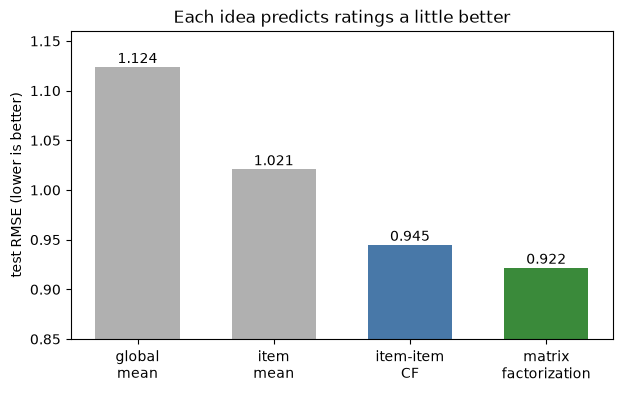

In [10]:
labels = ["global\nmean", "item\nmean", "item-item\nCF", "matrix\nfactorization"]
vals = [rmse_g, rmse_i, rmse_cf, rmse_mf]
colors = ["#b0b0b0", "#b0b0b0", "#4878a8", "#3a8a3a"]
plt.figure(figsize=(7, 4))
plt.bar(labels, vals, color=colors, width=0.62)
plt.ylim(0.85, 1.16); plt.ylabel("test RMSE (lower is better)")
plt.title("Each idea predicts ratings a little better")
for i, v in enumerate(vals):
    plt.text(i, v + 0.004, f"{v:.3f}", ha="center")
plt.show()

> **Interpretation:** each idea beats the one before -- global mean (1.124) -> item
> mean (1.021) -> item-item CF (0.945) -> matrix factorization (**0.922**). Knowing
> *which* movie helps; knowing how *similar* users/movies rate helps more; learning
> latent factors helps most. This ladder is the engine of the Netflix Prize. (RMSE
> here scores *rating prediction*; how well the top of the list is ordered -- ranking,
> e.g. precision@k -- is a related but separate question, taken up in L24.)

## Your Turn (Exercises)

### Exercise 1 -- A simple hybrid

In [11]:
# TODO: build a weighted hybrid for user 196. Compute the content-based cosine score
# for every movie (as in Step 1, before the top-N cut), min-max scale it to 0-1, and
# average it with the item-mean rating (also scaled to 0-1). Print the top-5 by the
# blended score. Does mixing the two signals change the list?

### Exercise 2 -- Written: pick the family for each cold start
For each scenario, name the recommender family you would use and why (1 sentence each):
(a) a brand-new user who has rated nothing; (b) a brand-new movie added today with no
ratings; (c) a shopper who states "I want a quiet hatchback under $20k."

## Summary

- **Content-based** recommends by item features (genre cosine); it handles new items
  but **over-specializes** (all one flavor).
- **Demographic** (cohorts) and **knowledge-based** (rules) need **no rating history**,
  so they cover the **cold start** that breaks collaborative filtering.
- **Hybrid** systems combine families -- the practical answer for real platforms.
- **Evaluate** with a held-out split: the **RMSE/MAE ladder** shows popularity -> item
  -> collaborative filtering -> matrix factorization, each a little better (1.124 ->
  1.021 -> 0.945 -> 0.922).
- Next, **L24** is the mini-project: choose signals, build a recommender end to end, and
  evaluate it yourself.